This model will replace anti viruses in small devices connected to internet
Working
It will monitor the internet traffic and in case ask resources collection
Whether the Request is Valid or False (Classification)
If false then thread level it contains (Regression)

On the Basis of above it will allow or disallow request.



## Importing necessary libraries

In [46]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, mean_squared_error

import xgboost as xgb


# Set display options
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

## Exploring the dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Read Train and Test dataset
data = pd.read_csv("/content/drive/MyDrive/DataSet/ISPaper/data.csv")

In [5]:
# Check data
data.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,outcome,level
0,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,121,19,0.0,0.0,1.0,1.0,0.16,0.06,0.00,255,19,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125972 entries, 0 to 125971
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125972 non-null  int64  
 1   protocol_type                125972 non-null  object 
 2   service                      125972 non-null  object 
 3   flag                         125972 non-null  object 
 4   src_bytes                    125972 non-null  int64  
 5   dst_bytes                    125972 non-null  int64  
 6   land                         125972 non-null  int64  
 7   wrong_fragment               125972 non-null  int64  
 8   urgent                       125972 non-null  int64  
 9   hot                          125972 non-null  int64  
 10  num_failed_logins            125972 non-null  int64  
 11  logged_in                    125972 non-null  int64  
 12  num_compromised              125972 non-null  int64  
 13 

In [7]:
data.describe().style.background_gradient(cmap='Blues').set_properties(**{'font-family':'Segoe UI'})

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,level
count,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000
mean,287.146929,45567.100824,19779.271433,0.000198,0.022688,0.000111,0.204411,0.001222,0.395739,0.279253,0.001342,0.001103,0.302194,0.012669,0.000413,0.004096,0.000000,0.000008,0.009423,84.108207,27.738093,0.284487,0.282488,0.119959,0.121184,0.660925,0.063053,0.097322,182.149200,115.653725,0.521244,0.082952,0.148379,0.032543,0.284455,0.278487,0.118832,0.120241,19.504056
std,2604.525522,5870354.480801,4021285.112114,0.014086,0.253531,0.014366,2.149977,0.045239,0.489011,23.942137,0.036603,0.045155,24.399715,0.483937,0.022181,0.099370,0.000000,0.002817,0.096613,114.508828,72.636092,0.446457,0.447024,0.320437,0.323648,0.439624,0.180315,0.259831,99.206565,110.702886,0.448950,0.188922,0.308998,0.112564,0.444785,0.445670,0.306559,0.319460,2.291512
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.090000,0.000000,0.000000,82.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.000000,44.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,8.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,255.000000,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.000000,276.000000,516.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,143.000000,18.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.060000,0.000000,255.000000,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.000000,1379963888.000000,1309937401.000000,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,1.000000,2.000000,7468.000000,43.000000,2.000000,9.000000,0.000000,1.000000,1.000000,511.000000,511.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [8]:
data.loc[data['outcome'] == "normal", "outcome"] = 'normal'
data.loc[data['outcome'] != 'normal', "outcome"] = 'attack'

In [9]:
def pie_plot(df, cols_list, rows, cols):
    fig, axes = plt.subplots(rows, cols)
    for ax, col in zip(axes.ravel(), cols_list):
        df[col].value_counts().plot(ax=ax, kind='pie', figsize=(15, 15), fontsize=10, autopct='%1.0f%%')
        ax.set_title(str(col), fontsize = 12)
    plt.show()

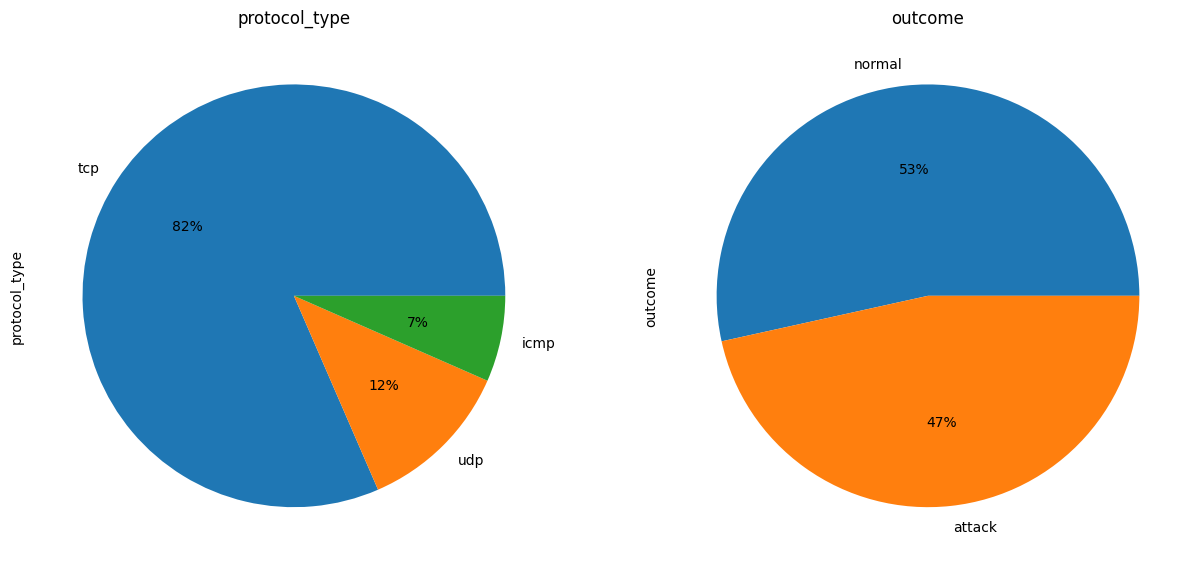

In [10]:
pie_plot(data, ['protocol_type', 'outcome'], 1, 2)

In [11]:
def label_encode_object_columns(df):
    # Make a copy of the input DataFrame to avoid modifying the original data
    encoded_df = df.copy()

    # Iterate through each column in the DataFrame
    for column in df.columns:
        # Check if the column is of type 'object' (usually indicates categorical data)
        if df[column].dtype == 'object':
            # Get unique values in the specified column
            unique_values = df[column].unique()

            # Create a mapping dictionary with numerical labels
            label_mapping = {value: index + 1 for index, value in enumerate(unique_values)}

            # Replace the values in the column with numerical labels
            encoded_df[column] = encoded_df[column].replace(label_mapping)

    return encoded_df

In [12]:
data_ = label_encode_object_columns(data)

x = data_.drop(['outcome', 'level'] , axis = 1)
y = data_['outcome']
yreg = data_['level']

In [13]:
data

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,outcome,level
0,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,attack,19
2,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,121,19,0.0,0.0,1.0,1.0,0.16,0.06,0.00,255,19,0.07,0.07,0.00,0.00,0.00,0.00,1.00,1.00,attack,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125967,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,184,25,1.0,1.0,0.0,0.0,0.14,0.06,0.00,255,25,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,attack,20
125968,8,udp,private,SF,105,145,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.00,0.00,0.00,255,244,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125969,0,tcp,smtp,SF,2231,384,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0.0,0.0,0.0,0.0,1.00,0.00,0.00,255,30,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125970,0,tcp,klogin,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,144,8,1.0,1.0,0.0,0.0,0.06,0.05,0.00,255,8,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,attack,20


In [14]:
data_

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,outcome,level
0,0,1,1,1,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,1,15
1,0,2,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,2,19
2,0,2,3,1,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,1,21
3,0,2,3,1,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1,21
4,0,2,2,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,121,19,0.0,0.0,1.0,1.0,0.16,0.06,0.00,255,19,0.07,0.07,0.00,0.00,0.00,0.00,1.00,1.00,2,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125967,0,2,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,184,25,1.0,1.0,0.0,0.0,0.14,0.06,0.00,255,25,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,2,20
125968,8,1,2,1,105,145,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.00,0.00,0.00,255,244,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,1,21
125969,0,2,16,1,2231,384,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0.0,0.0,0.0,0.0,1.00,0.00,0.00,255,30,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,1,18
125970,0,2,36,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,144,8,1.0,1.0,0.0,0.0,0.06,0.05,0.00,255,8,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,2,20


In [15]:
data_.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125972 entries, 0 to 125971
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125972 non-null  int64  
 1   protocol_type                125972 non-null  int64  
 2   service                      125972 non-null  int64  
 3   flag                         125972 non-null  int64  
 4   src_bytes                    125972 non-null  int64  
 5   dst_bytes                    125972 non-null  int64  
 6   land                         125972 non-null  int64  
 7   wrong_fragment               125972 non-null  int64  
 8   urgent                       125972 non-null  int64  
 9   hot                          125972 non-null  int64  
 10  num_failed_logins            125972 non-null  int64  
 11  logged_in                    125972 non-null  int64  
 12  num_compromised              125972 non-null  int64  
 13 

In [16]:
correlation_matrix_y = x.corrwith(y)
correlation_matrix_y_reg = x.corrwith(y)

threshold = 0.1  # You can adjust this threshold

filtered_x = x.drop(correlation_matrix_y[abs(correlation_matrix_y) < threshold].index, axis=1)
filtered_x_reg = x.drop(correlation_matrix_y_reg[abs(correlation_matrix_y_reg) < threshold].index, axis=1)

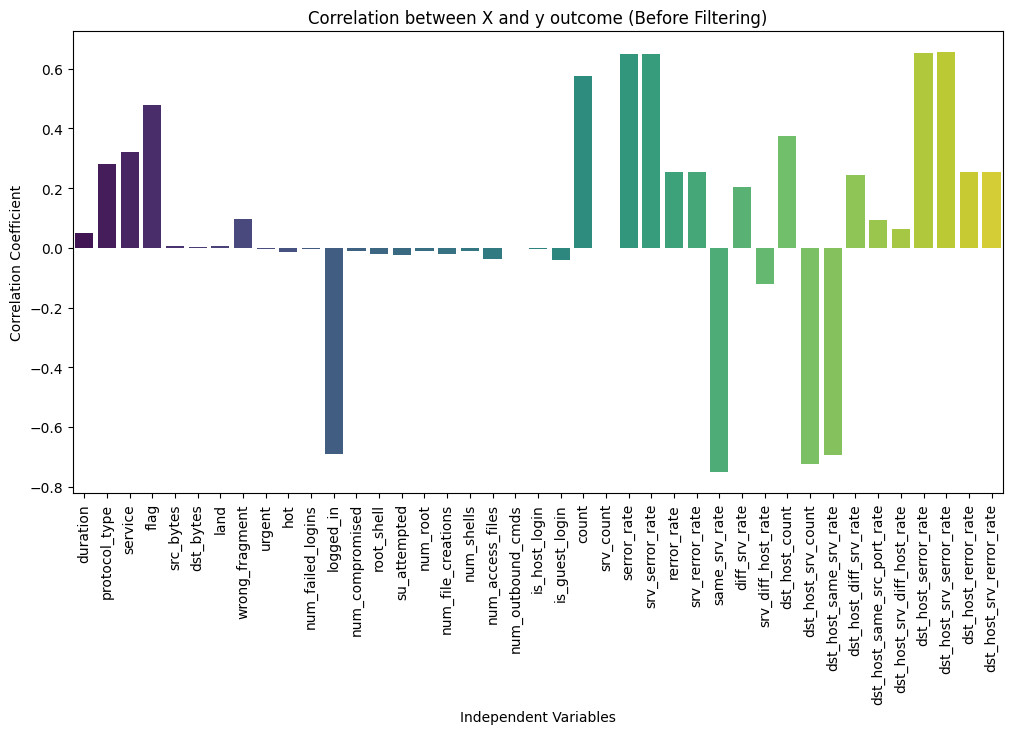

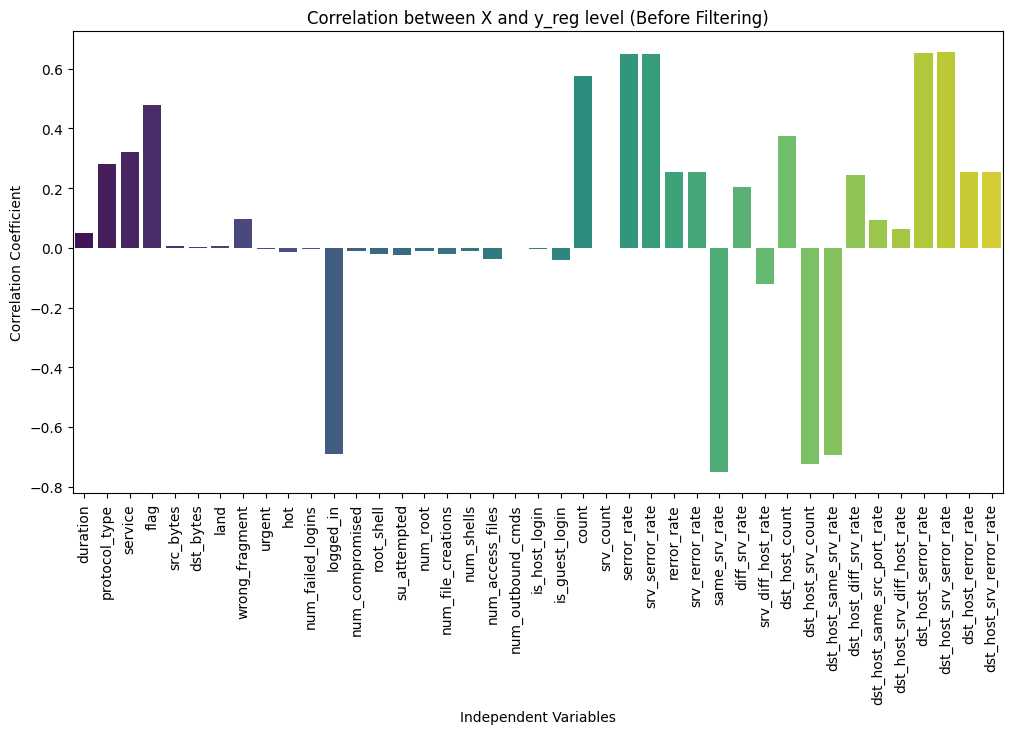

In [17]:
# Plot correlation with y before filtering
plt.figure(figsize=(12, 6))
sns.barplot(x=correlation_matrix_y.index, y=correlation_matrix_y.values, palette='viridis')
plt.title('Correlation between X and y outcome (Before Filtering)')
plt.xlabel('Independent Variables')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=90)
plt.savefig('correlation_with_y_plot_before_filtering.png', dpi=750)
plt.show()

# Plot correlation with y_reg before filtering
plt.figure(figsize=(12, 6))
sns.barplot(x=correlation_matrix_y_reg.index, y=correlation_matrix_y_reg.values, palette='viridis')
plt.title('Correlation between X and y_reg level (Before Filtering)')
plt.xlabel('Independent Variables')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=90)
plt.savefig('correlation_with_y_reg_plot_before_filtering.png', dpi=750)
plt.show()

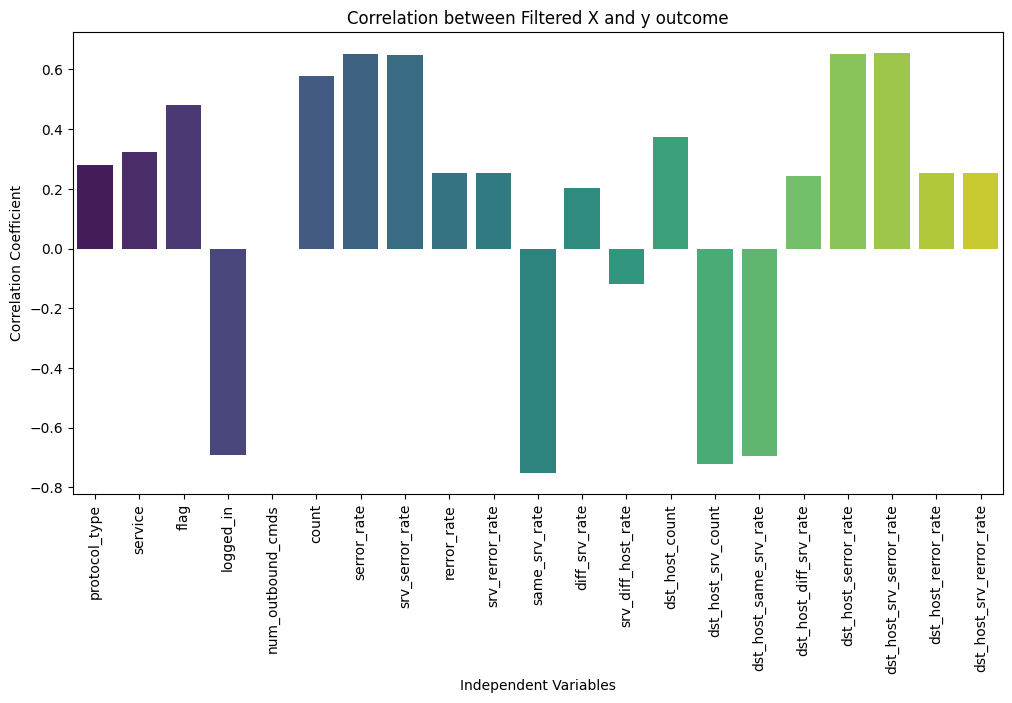

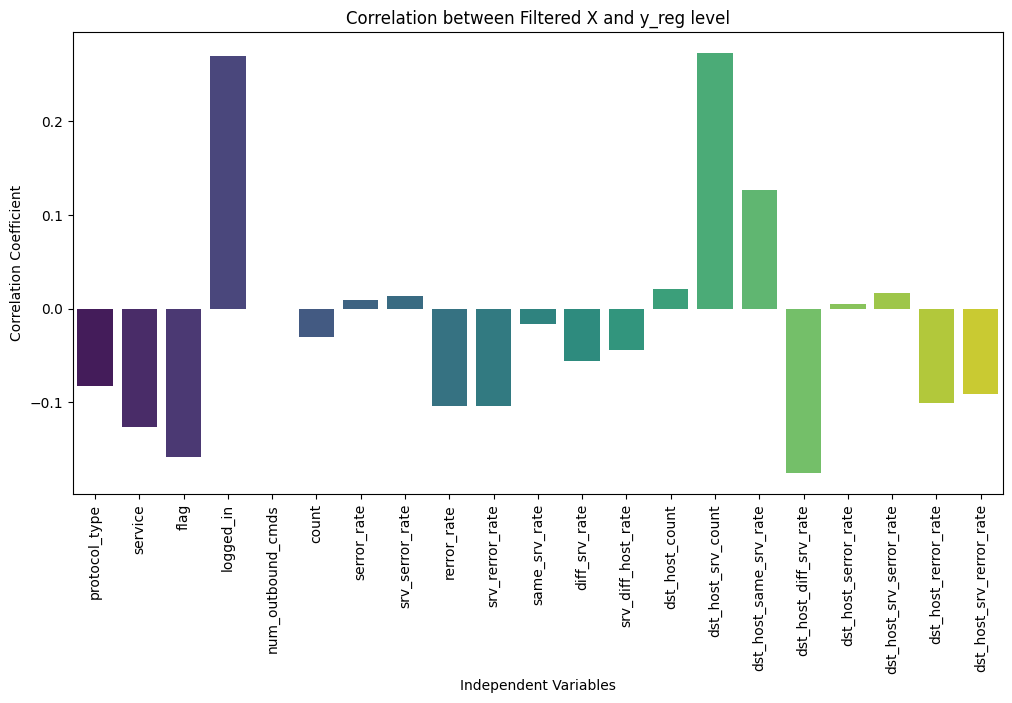

In [18]:
# Plot correlation with y after filtering
correlation_matrix_filtered_x = filtered_x.corrwith(y)
plt.figure(figsize=(12, 6))
sns.barplot(x=correlation_matrix_filtered_x.index, y=correlation_matrix_filtered_x.values, palette='viridis')
plt.title('Correlation between Filtered X and y outcome')
plt.xlabel('Independent Variables')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=90)
plt.show()

# Plot correlation with y_reg after filtering
correlation_matrix_filtered_x_reg = filtered_x_reg.corrwith(yreg)
plt.figure(figsize=(12, 6))
sns.barplot(x=correlation_matrix_filtered_x_reg.index, y=correlation_matrix_filtered_x_reg.values, palette='viridis')
plt.title('Correlation between Filtered X and y_reg level')
plt.xlabel('Independent Variables')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=90)
plt.show()

In [19]:
filtered_x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125972 entries, 0 to 125971
Data columns (total 21 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   protocol_type             125972 non-null  int64  
 1   service                   125972 non-null  int64  
 2   flag                      125972 non-null  int64  
 3   logged_in                 125972 non-null  int64  
 4   num_outbound_cmds         125972 non-null  int64  
 5   count                     125972 non-null  int64  
 6   serror_rate               125972 non-null  float64
 7   srv_serror_rate           125972 non-null  float64
 8   rerror_rate               125972 non-null  float64
 9   srv_rerror_rate           125972 non-null  float64
 10  same_srv_rate             125972 non-null  float64
 11  diff_srv_rate             125972 non-null  float64
 12  srv_diff_host_rate        125972 non-null  float64
 13  dst_host_count            125972 non-null  i

In [20]:
filtered_x_reg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125972 entries, 0 to 125971
Data columns (total 21 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   protocol_type             125972 non-null  int64  
 1   service                   125972 non-null  int64  
 2   flag                      125972 non-null  int64  
 3   logged_in                 125972 non-null  int64  
 4   num_outbound_cmds         125972 non-null  int64  
 5   count                     125972 non-null  int64  
 6   serror_rate               125972 non-null  float64
 7   srv_serror_rate           125972 non-null  float64
 8   rerror_rate               125972 non-null  float64
 9   srv_rerror_rate           125972 non-null  float64
 10  same_srv_rate             125972 non-null  float64
 11  diff_srv_rate             125972 non-null  float64
 12  srv_diff_host_rate        125972 non-null  float64
 13  dst_host_count            125972 non-null  i

## Preprocessing the data

In [23]:
# Standardize filtered_x
scaler_x = StandardScaler()
standardized_filtered_x = scaler_x.fit_transform(filtered_x)

# Standardize filtered_x_reg
scaler_x_reg = StandardScaler()
standardized_filtered_x_reg = scaler_x_reg.fit_transform(filtered_x_reg)

In [24]:
print("Shape of standardized_filtered_x:", standardized_filtered_x.shape)
print("Shape of y:", y.shape)
print("Shape of standardized_filtered_x_reg:", standardized_filtered_x_reg.shape)
print("Shape of yreg:", yreg.shape)

Shape of standardized_filtered_x: (125972, 21)
Shape of y: (125972,)
Shape of standardized_filtered_x_reg: (125972, 21)
Shape of yreg: (125972,)


## Training Testing Evaluate

In [25]:
# Split into training, validation, and test sets
x_train, x_temp, y_train, y_temp = train_test_split(
    standardized_filtered_x, y, test_size=0.4, random_state=42)

x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.5, random_state=42)

# Repeat the process for standardized_filtered_x_reg and yreg
x_train_reg, x_temp_reg, y_train_reg, y_temp_reg = train_test_split(
    standardized_filtered_x_reg, yreg, test_size=0.4, random_state=42)

x_val_reg, x_test_reg, y_val_reg, y_test_reg = train_test_split(
    x_temp_reg, y_temp_reg, test_size=0.5, random_state=42)

# Print shapes to verify
print("Shapes after splitting:")
print("Training set shapes:", x_train.shape, y_train.shape)
print("Validation set shapes:", x_val.shape, y_val.shape)
print("Test set shapes:", x_test.shape, y_test.shape)

print("\nShapes for standardized_filtered_x_reg and yreg:")
print("Training set shapes:", x_train_reg.shape, y_train_reg.shape)
print("Validation set shapes:", x_val_reg.shape, y_val_reg.shape)
print("Test set shapes:", x_test_reg.shape, y_test_reg.shape)


Shapes after splitting:
Training set shapes: (75583, 21) (75583,)
Validation set shapes: (25194, 21) (25194,)
Test set shapes: (25195, 21) (25195,)

Shapes for standardized_filtered_x_reg and yreg:
Training set shapes: (75583, 21) (75583,)
Validation set shapes: (25194, 21) (25194,)
Test set shapes: (25195, 21) (25195,)


In [31]:
def plot_confusion_matrix(y_true, y_pred, set_name, model_name):
    conf_matrix = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=["Class 0", "Class 1"])
    disp.plot(cmap="Blues", values_format=".0f")
    plt.title(f"{model_name} Confusion Matrix - {set_name} Set")

    plt.savefig(f"/content/{model_name}_confusion_matrix_{set_name}.png", dpi=300)

    plt.show()

### Modeling
The process of modeling means training a machine learning algorithm to predict the labels from the features, tuning it for the business need, and validating it on holdout data. The output from modeling is a trained model that can be used for inference, making predictions on new data points.

<img src="https://docs.microsoft.com/en-us/windows/ai/images/winml-model-flow.png" width="600"/>

A machine learning model itself is a file that has been trained to recognize certain types of patterns. You train a model over a set of data, providing it an algorithm that it can use to reason over and learn from those data.
Once you have trained the model, you can use it to reason over data that it hasn't seen before, and make predictions about those data. For example, let's say you want to build an application that can recognize a user's emotions based on their facial expressions. You can train a model by providing it with images of faces that are each tagged with a certain emotion, and then you can use that model in an application that can recognize any user's emotion

### Support Vector Machines

Support Vector Machine (SVM) is a relatively simple Supervised Machine Learning Algorithm used for classification and/or regression. It is more preferred for classification but is sometimes very useful for regression as well. Basically, SVM finds a hyper-plane that creates a boundary between the types of data. In 2-dimensional space, this hyper-plane is nothing but a line. In SVM, we plot each data item in the dataset in an N-dimensional space, where N is the number of features/attributes in the data. Next, find the optimal hyperplane to separate the data. So by this, you must have understood that inherently, SVM can only perform binary classification (i.e., choose between two classes). However, there are various techniques to use for multi-class problems. Support Vector Machine for Multi-CLass Problems To perform SVM on multi-class problems, we can create a binary classifier for each class of the data. The two results of each classifier will be :

* The data point belongs to that class OR
* The data point does not belong to that class.

<img src=https://lh5.googleusercontent.com/Fqswkk7bY0_7EhTgbPWNOexWWzzDplNKYc1bJl6MI_edNVdwXnWI5xkoSyl7SxFHLLAWlW1AIEhWF2ilVvThzuU0HoPBNF79HsPezpXnKTv3DCFnD9ZeVPLmR828_JXpv5cB35TL width=600/>

For example, in a class of fruits, to perform multi-class classification, we can create a binary classifier for each fruit. For say, the ‘mango’ class, there will be a binary classifier to predict if it IS a mango OR it is NOT a mango. The classifier with the highest score is chosen as the output of the SVM. SVM for complex (Non Linearly Separable) SVM works very well without any modifications for linearly separable data. Linearly Separable Data is any data that can be plotted in a graph and can be separated into classes using a straight line.

We use Kernelized SVM for non-linearly separable data. Say, we have some non-linearly separable data in one dimension. We can transform this data into two dimensions and the data will become linearly separable in two dimensions. This is done by mapping each 1-D data point to a corresponding 2-D ordered pair. So for any non-linearly separable data in any dimension, we can just map the data to a higher dimension and then make it linearly separable. This is a very powerful and general transformation. A kernel is nothing but a measure of similarity between data points. The kernel function in a kernelized SVM tells you, that given two data points in the original feature space, what the similarity is between the points in the newly transformed feature space. There are various kernel functions available, but two are very popular :

* Radial Basis Function Kernel (RBF): The similarity between two points in the transformed feature space is an exponentially decaying function of the distance between the vectors and the original input space as shown below. RBF is the default kernel used in SVM.

* Polynomial Kernel: The Polynomial kernel takes an additional parameter, ‘degree’ that controls the model’s complexity and computational cost of the transformation

In [29]:
# Train the LinearSVC model
lin_svc = LinearSVC(random_state=42)
lin_svc.fit(x_train, y_train)

# Evaluate the model on training set
y_train_pred = lin_svc.predict(x_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")

# Evaluate the model on validation set
y_val_pred = lin_svc.predict(x_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

# Evaluate the model on test set
y_test_pred = lin_svc.predict(x_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


Training Accuracy: 94.48%
Validation Accuracy: 94.40%
Test Accuracy: 94.33%


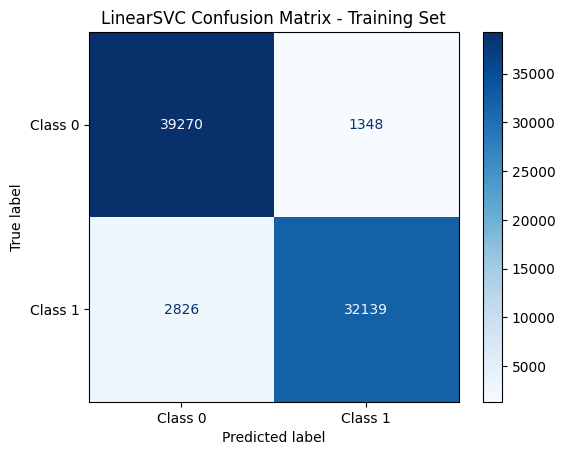

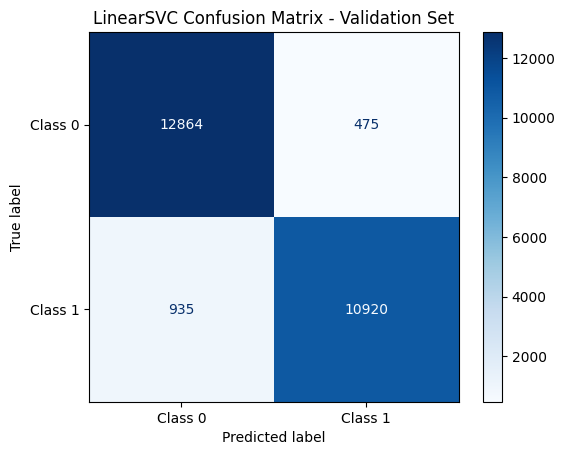

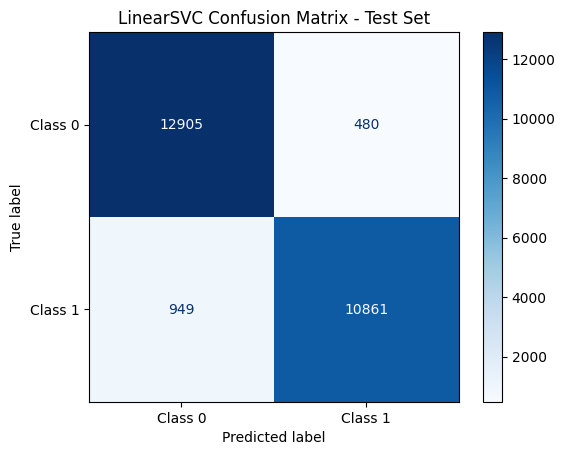

In [32]:
plot_confusion_matrix(y_train, y_train_pred, "Training","LinearSVC")
plot_confusion_matrix(y_val, y_val_pred, "Validation","LinearSVC")
plot_confusion_matrix(y_test, y_test_pred, "Test","LinearSVC")

### Decision Tree
Decision Tree is the most powerful and popular tool for classification and prediction. A Decision tree is a flowchart-like tree structure, where each internal node denotes a test on an attribute, each branch represents an outcome of the test, and each leaf node (terminal node) holds a class label.

<img src= https://www.mastersindatascience.org/wp-content/uploads/sites/54/2022/05/tree-graphic.jpg width=500/>

A tree can be “learned” by splitting the source set into subsets based on an attribute value test. This process is repeated on each derived subset in a recursive manner called recursive partitioning. The recursion is completed when the subset at a node all has the same value of the target variable, or when splitting no longer adds value to the predictions.Decision trees classify instances by sorting them down the tree from the root to some leaf node, which provides the classification of the instance. An instance is classified by starting at the root node of the tree, testing the attribute specified by this node, then moving down the tree branch corresponding to the value of the attribute as shown in the above figure. This process is then repeated for the subtree rooted at the new node.
The decision tree in above figure classifies a particular morning according to whether it is suitable for playing tennis and returning the classification associated with the particular leaf.(in this case Yes or No).

In [33]:
# Train the DecisionTreeClassifier model with max depth
dt_max_depth = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_max_depth.fit(x_train, y_train)

# Evaluate the model with max depth on training set
y_train_pred_max_depth = dt_max_depth.predict(x_train)
train_accuracy_max_depth = accuracy_score(y_train, y_train_pred_max_depth)
print(f"Training Accuracy (Max Depth): {train_accuracy_max_depth * 100:.2f}%")

# Evaluate the model with max depth on validation set
y_val_pred_max_depth = dt_max_depth.predict(x_val)
val_accuracy_max_depth = accuracy_score(y_val, y_val_pred_max_depth)
print(f"Validation Accuracy (Max Depth): {val_accuracy_max_depth * 100:.2f}%")

# Evaluate the model with max depth on test set
y_test_pred_max_depth = dt_max_depth.predict(x_test)
test_accuracy_max_depth = accuracy_score(y_test, y_test_pred_max_depth)
print(f"Test Accuracy (Max Depth): {test_accuracy_max_depth * 100:.2f}%")

Training Accuracy (Max Depth): 95.51%
Validation Accuracy (Max Depth): 95.44%
Test Accuracy (Max Depth): 95.50%


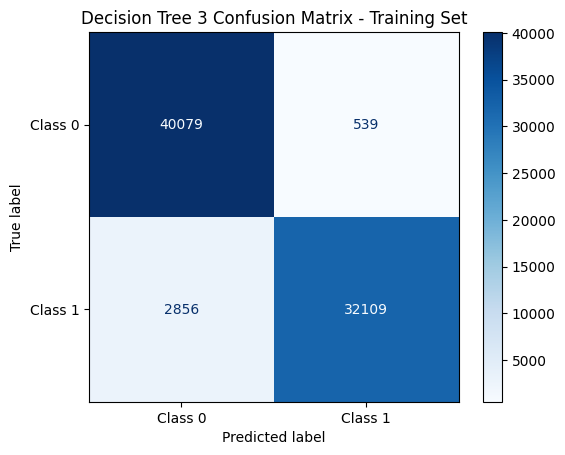

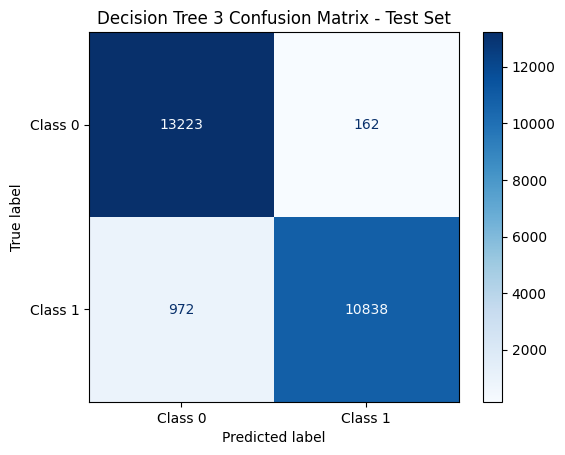

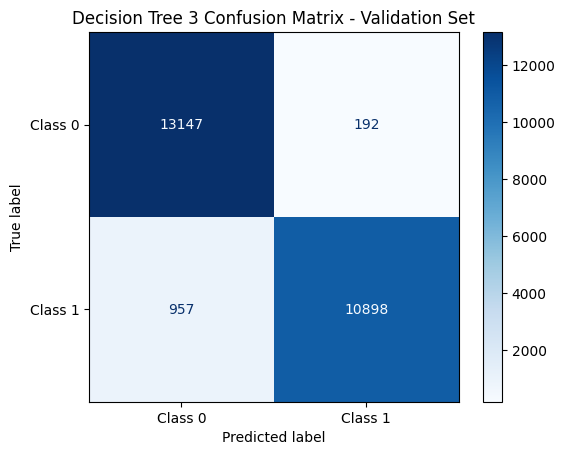

In [34]:
plot_confusion_matrix(y_train, y_train_pred_max_depth, "Training","Decision Tree 3")
plot_confusion_matrix(y_test, y_test_pred_max_depth, "Test","Decision Tree 3")
plot_confusion_matrix(y_val, y_val_pred_max_depth, "Validation","Decision Tree 3")

In [35]:
# Train the DecisionTreeClassifier model without max depth
dt_no_max_depth = DecisionTreeClassifier(random_state=42)
dt_no_max_depth.fit(x_train, y_train)

# Evaluate the model without max depth on training set
y_train_pred_no_max_depth = dt_no_max_depth.predict(x_train)
train_accuracy_no_max_depth = accuracy_score(y_train, y_train_pred_no_max_depth)
print(f"Training Accuracy (No Max Depth): {train_accuracy_no_max_depth * 100:.2f}%")

# Evaluate the model without max depth on validation set
y_val_pred_no_max_depth = dt_no_max_depth.predict(x_val)
val_accuracy_no_max_depth = accuracy_score(y_val, y_val_pred_no_max_depth)
print(f"Validation Accuracy (No Max Depth): {val_accuracy_no_max_depth * 100:.2f}%")

# Evaluate the model without max depth on test set
y_test_pred_no_max_depth = dt_no_max_depth.predict(x_test)
test_accuracy_no_max_depth = accuracy_score(y_test, y_test_pred_no_max_depth)
print(f"Test Accuracy (No Max Depth): {test_accuracy_no_max_depth * 100:.2f}%")

Training Accuracy (No Max Depth): 99.93%
Validation Accuracy (No Max Depth): 99.48%
Test Accuracy (No Max Depth): 99.44%


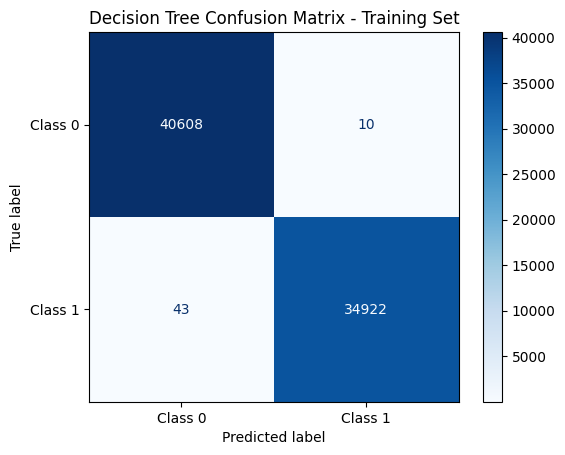

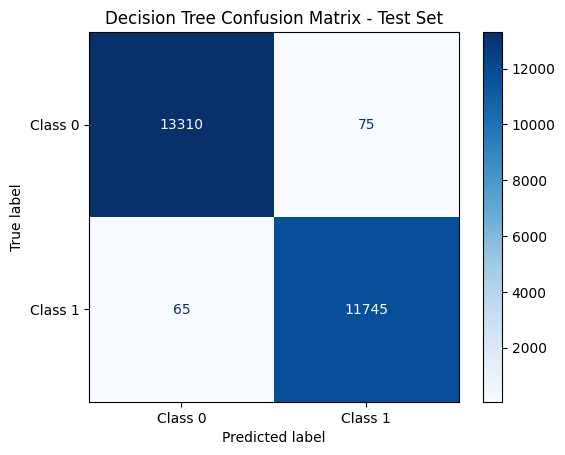

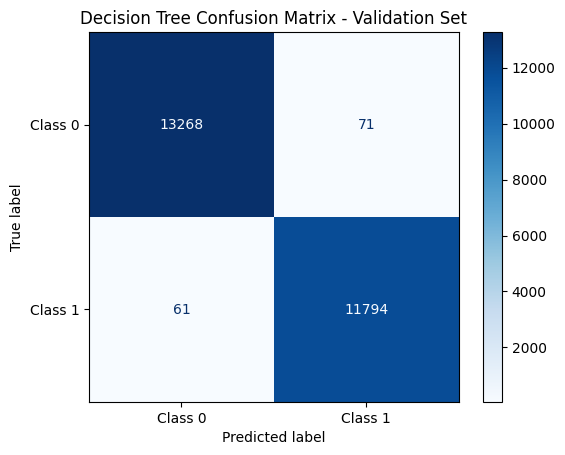

In [36]:
# Example usage
plot_confusion_matrix(y_train, y_train_pred_no_max_depth, "Training","Decision Tree")
plot_confusion_matrix(y_test, y_test_pred_no_max_depth, "Test","Decision Tree")
plot_confusion_matrix(y_val, y_val_pred_no_max_depth, "Validation","Decision Tree")

[Text(0.5, 0.875, 'x[2] <= -0.119\ngini = 0.497\nsamples = 75583\nvalue = [40618, 34965]'),
 Text(0.25, 0.625, 'x[0] <= 1.297\ngini = 0.258\nsamples = 45117\nvalue = [38241, 6876]'),
 Text(0.125, 0.375, 'x[1] <= -0.641\ngini = 0.127\nsamples = 40209\nvalue = [37472, 2737]'),
 Text(0.0625, 0.125, 'gini = 0.487\nsamples = 3649\nvalue = [2117, 1532]'),
 Text(0.1875, 0.125, 'gini = 0.064\nsamples = 36560\nvalue = [35355, 1205]'),
 Text(0.375, 0.375, 'x[10] <= 0.646\ngini = 0.264\nsamples = 4908\nvalue = [769, 4139]'),
 Text(0.3125, 0.125, 'gini = 0.04\nsamples = 436\nvalue = [427, 9]'),
 Text(0.4375, 0.125, 'gini = 0.141\nsamples = 4472\nvalue = [342, 4130]'),
 Text(0.75, 0.625, 'x[15] <= 0.164\ngini = 0.144\nsamples = 30466\nvalue = [2377, 28089]'),
 Text(0.625, 0.375, 'x[3] <= 0.213\ngini = 0.024\nsamples = 28246\nvalue = [337, 27909]'),
 Text(0.5625, 0.125, 'gini = 0.013\nsamples = 28088\nvalue = [190, 27898]'),
 Text(0.6875, 0.125, 'gini = 0.13\nsamples = 158\nvalue = [147, 11]'),
 Tex

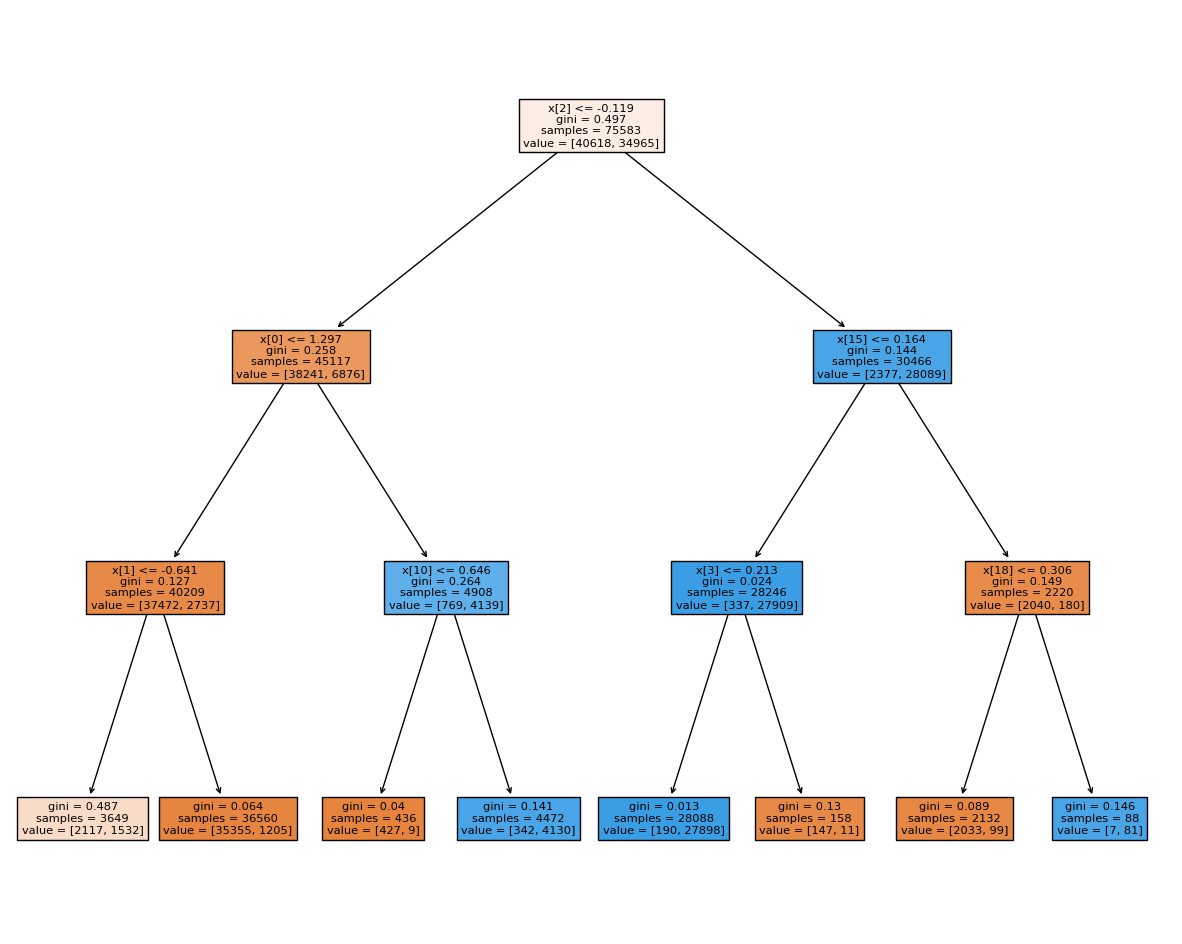

In [40]:
fig = plt.figure(figsize=(15,12))
plot_tree(dt_max_depth , filled=True)

### RandomForest

In [41]:
# Train the RandomForestClassifier model
random_forest = RandomForestClassifier(random_state=42)
random_forest.fit(x_train, y_train)

# Evaluate the RandomForestClassifier model on training set
y_train_pred_rf = random_forest.predict(x_train)
train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
print(f"RandomForest Training Accuracy: {train_accuracy_rf * 100:.2f}%")

# Evaluate the RandomForestClassifier model on validation set
y_val_pred_rf = random_forest.predict(x_val)
val_accuracy_rf = accuracy_score(y_val, y_val_pred_rf)
print(f"RandomForest Validation Accuracy: {val_accuracy_rf * 100:.2f}%")

# Evaluate the RandomForestClassifier model on test set
y_test_pred_rf = random_forest.predict(x_test)
test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
print(f"RandomForest Test Accuracy: {test_accuracy_rf * 100:.2f}%")

RandomForest Training Accuracy: 99.93%
RandomForest Validation Accuracy: 99.60%
RandomForest Test Accuracy: 99.57%


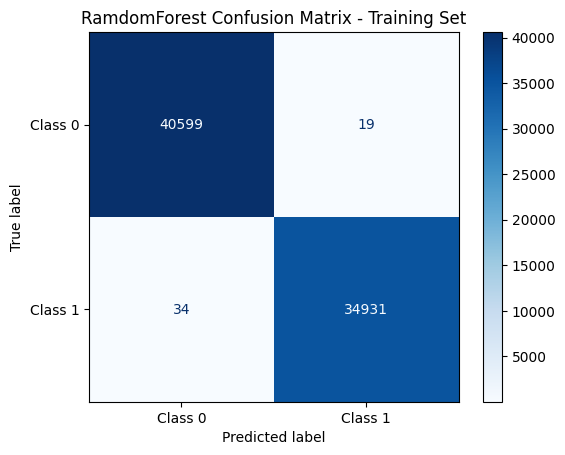

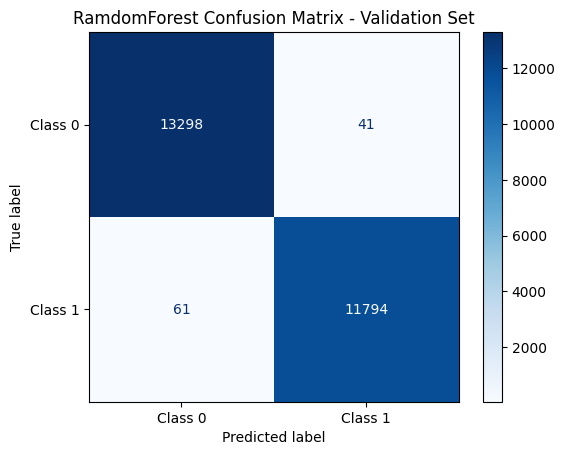

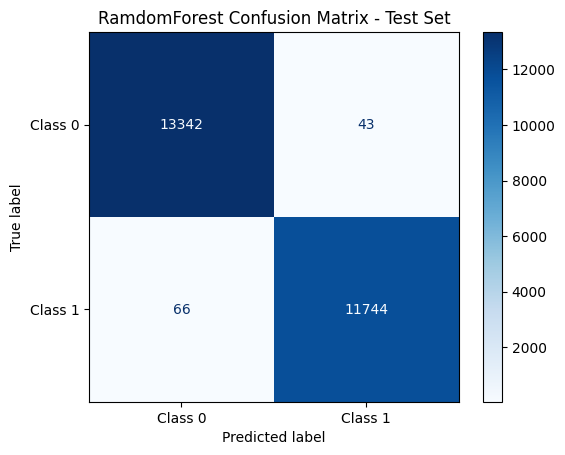

In [43]:
plot_confusion_matrix(y_train, y_train_pred_rf, "Training","RamdomForest")
plot_confusion_matrix(y_val, y_val_pred_rf, "Validation","RamdomForest")
plot_confusion_matrix(y_test, y_test_pred_rf, "Test","RamdomForest")

### Building an XGBOOST Regressor regressor in order to predict Threat Level

In [47]:
# Train the XGBoost regressor
xg_r = xgb.XGBRegressor(objective='reg:linear', n_estimators=20).fit(x_train_reg, y_train_reg)

# Predictions on the training set
y_train_pred = xg_r.predict(x_train_reg)
mse_train = mean_squared_error(y_train_reg, y_train_pred)

# Predictions on the validation set
y_val_pred = xg_r.predict(x_val_reg)
mse_val = mean_squared_error(y_val_reg, y_val_pred)

# Predictions on the test set
y_test_pred = xg_r.predict(x_test_reg)
mse_test = mean_squared_error(y_test_reg, y_test_pred)

# Print MSE values
print("Mean Squared Error (MSE) for the training set:", mse_train)
print("Mean Squared Error (MSE) for the test set:", mse_test)
print("Mean Squared Error (MSE) for the validation set:", mse_val)

Mean Squared Error (MSE) for the training set: 1.1678104449135538
Mean Squared Error (MSE) for the test set: 1.3131234207110196
Mean Squared Error (MSE) for the validation set: 1.257466355909439


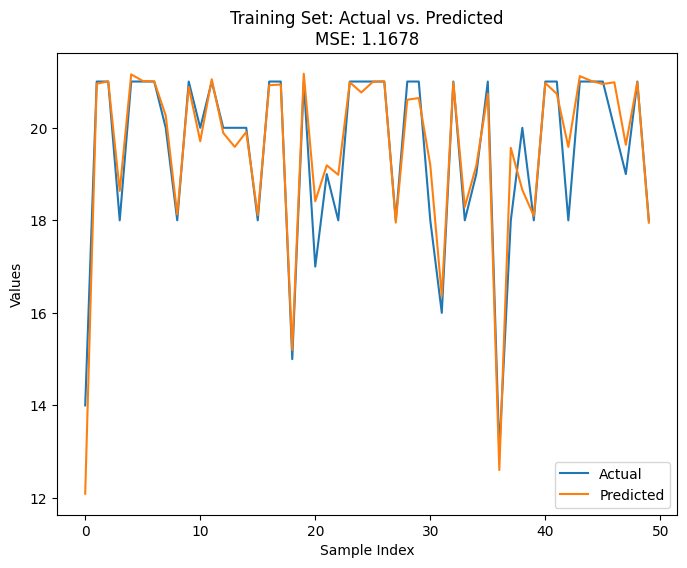

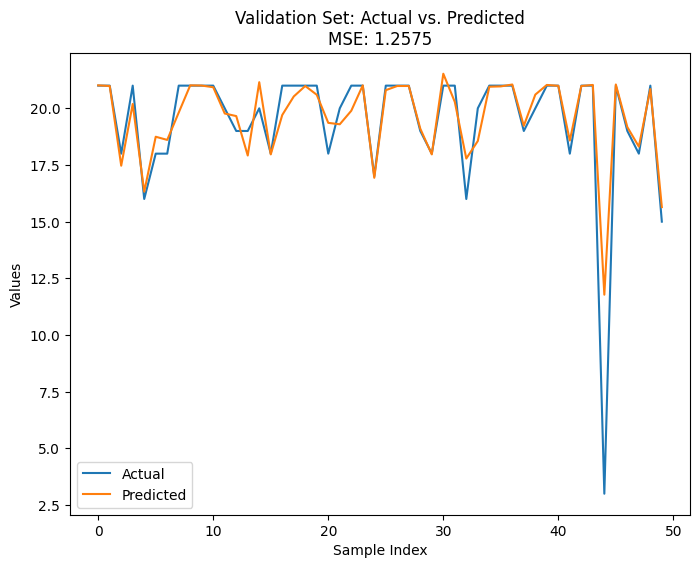

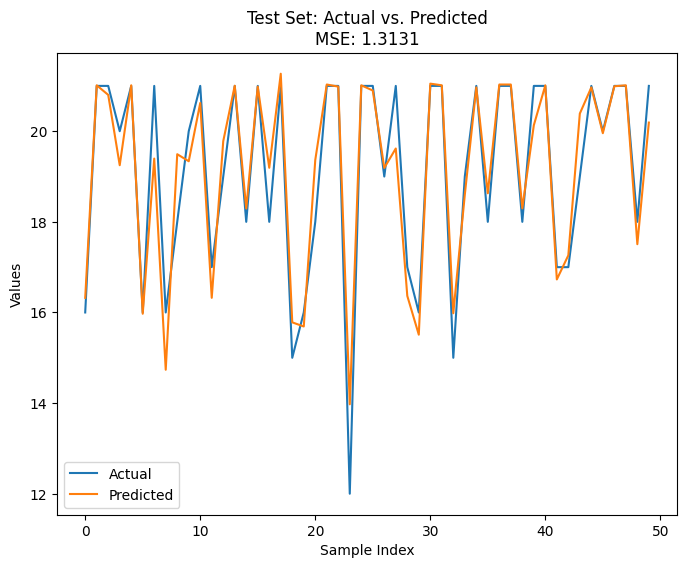

In [49]:
# Create DataFrames for plotting
df_train = pd.DataFrame({"Actual": y_train_reg[:50], "Predicted": y_train_pred[:50]})
df_val = pd.DataFrame({"Actual": y_val_reg[:50], "Predicted": y_val_pred[:50]})
df_test = pd.DataFrame({"Actual": y_test_reg[:50], "Predicted": y_test_pred[:50]})

# Plotting and saving the training set plot
plt.figure(figsize=(8, 6))
plt.plot(np.arange(len(df_train)), df_train["Actual"], label='Actual')
plt.plot(np.arange(len(df_train)), df_train["Predicted"], label='Predicted')
plt.title(f'Training Set: Actual vs. Predicted\nMSE: {mse_train:.4f}')
plt.xlabel('Sample Index')
plt.ylabel('Values')
plt.legend()
plt.savefig('training_set_plot.png')
plt.show()

# Plotting and saving the validation set plot
plt.figure(figsize=(8, 6))
plt.plot(np.arange(len(df_val)), df_val["Actual"], label='Actual')
plt.plot(np.arange(len(df_val)), df_val["Predicted"], label='Predicted')
plt.title(f'Validation Set: Actual vs. Predicted\nMSE: {mse_val:.4f}')
plt.xlabel('Sample Index')
plt.ylabel('Values')
plt.legend()
plt.savefig('validation_set_plot.png')
plt.show()

# Plotting and saving the test set plot
plt.figure(figsize=(8, 6))
plt.plot(np.arange(len(df_test)), df_test["Actual"], label='Actual')
plt.plot(np.arange(len(df_test)), df_test["Predicted"], label='Predicted')
plt.title(f'Test Set: Actual vs. Predicted\nMSE: {mse_test:.4f}')
plt.xlabel('Sample Index')
plt.ylabel('Values')
plt.legend()
plt.savefig('test_set_plot.png')
plt.show()